# Dev check: in-schedule VoltageOffset flux pulse vs. SetParameter idle bias

**Not a numbered calibration node.** This notebook is Phase 0 of the calibration-node
rollout plan: it checks whether a schedule-internal `VoltageOffset` flux pulse can
coexist with the existing external `SetParameter` idle bias, and whether the voltage
correctly returns to that idle bias once the pulse ends.

**Before running on real hardware:** start with a small `FLUX_PULSE_START`/`FLUX_PULSE_STOP`
range (well inside a range you already trust from `run05_resonator_flux_spectroscopy`), and
only widen it after confirming the sweet-spot curve below matches a SetParameter-based
`ResonatorFluxSpectroscopy` run of the same qubit.

In [9]:
from pathlib import Path

from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.config.sessions import CONFIG_DIR, SESSIONS
from qblox_lab.experiments.dev_joint_flux_pulse_check import JointFluxPulseCheck

## Run parameters

In [10]:
SESSION = SESSIONS["AS_QRC"]
HARDWARE_CONFIG = SESSION.hardware_config
DEVICE_CONFIG = SESSION.device_config
FLUX_CONFIG = SESSION.flux_config # Idle bias applied before the pulse sweep
OUTPUT_DIR = Path("data")

QUBIT = "q1"
FREQUENCY_CENTER = None
FREQUENCY_WIDTH = 30e6
FREQUENCY_POINTS = 201

# Conservative first pass: a small delta on top of the already-applied idle bias.
# Widen only after this range reproduces the expected sweet-spot shift.
FLUX_PULSE_START = -0.05
FLUX_PULSE_STOP = 0.05
FLUX_PULSE_POINTS = 11
REPETITIONS = 5
PULSE_SETTLE_TIME = 1e-6
IDLE_RETURN_TIME = 1e-6

TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True

## Hardware and experiment

In [11]:
hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = JointFluxPulseCheck(
    hardware_agent=hardware_agent,
    qubit=QUBIT,
    flux_config=FLUX_CONFIG,
)

## Part 2: held flux pulse + CW drive, matching cal07b

Second question this dev module answers: does a continuous-wave drive held on
top of a flux pulse -- both held across the whole frequency sweep for one
flux point -- reproduce a qubit flux spectroscopy sweet spot the same way
`cal07b_CW_flux_qubit_spectroscopy.py`'s `MultiplexedCWFluxQubitSpectroscopy`
does on real hardware.

An earlier version of this check instead pulsed away from idle, drove for a
fixed duration, and pulsed back to idle *before* the readout -- so a future
`cal08_qubit_flux_spectroscopy.py` could always read out at the idle-tuned
resonator frequency. That timing was dropped from `JointFluxPulseDriveCheck`:
its preview showed the flux/drive pulses failing to render, and its first
real run's automatic fit failed (too few flux columns had a detectable dip
inside the frequency window, because the per-shot idle-return timing was
unvalidated). Revisit that idea as a separate check once this CW baseline is
confirmed.

Each shot is one strictly sequential chain (no `ref_op`, to sidestep the
confirmed `qblox_scheduler` compiler bug for `ref_op`-aligned flux-port
pulses), per flux point: flux pulse on -> settle -> for each frequency point,
drive re-asserted -> `SetClockFrequency` -> `Reset` (steady-state wait under
continuous drive, not a return to idle) -> `Measure` (still flux-shifted and
driven) -> after the frequency loop, drive off -> flux pulse back to 0 V
(idle) -> settle.

**Before running on real hardware:** same caution as Part 1 -- start with a
small `FLUX_PULSE_START`/`FLUX_PULSE_STOP` range you already trust from
`run08_qubit_flux_spectroscopy`, and a conservative `DRIVE_AMPLITUDE`.


In [12]:
from qblox_lab.experiments.dev_joint_flux_pulse_check import JointFluxPulseDriveCheck

### Run parameters

In [13]:
QUBIT_2 = "q1"
FREQUENCY_CENTER_2 = None
FREQUENCY_WIDTH_2 = 100e6
FREQUENCY_POINTS_2 = 101
DRIVE_AMPLITUDE_2 = 0.05

# Conservative first pass: a small delta on top of the already-applied idle bias.
# Widen only after this range reproduces the expected sweet-spot shift.
FLUX_PULSE_START_2 = -0.05
FLUX_PULSE_STOP_2 = 0.05
FLUX_PULSE_POINTS_2 = 51
REPETITIONS_2 = 100
PULSE_SETTLE_TIME_2 = 1e-6
IDLE_RETURN_TIME_2 = 1e-6

TIMEOUT_2 = 300

PLOT_RESULTS_2 = True


### Hardware and experiment

Reuses the `hardware_agent` created in Part 1 -- same cluster connection, same idle
bias mechanism (`apply_flux_config`), just a different experiment object.

In [14]:
drive_experiment = JointFluxPulseDriveCheck(
    hardware_agent=hardware_agent,
    qubit=QUBIT_2,
    flux_config=FLUX_CONFIG,
)

### Optional: view the compiled pulse schedule

`build_schedule()` wraps the sweep in nested hardware loops that compile to a single
opaque `LoopOperation`, which `plot_pulse_diagram()` can't render. `preview_pulse_schedule()`
builds the same held-flux/held-drive chain by hand -- flux pulsed on once, drive
re-asserted at each of a couple of frequency offsets, both held for the whole span, then
both switched off -- use this to visually confirm the flux pulse (on the flux AWG
module), the drive (on the microwave AWG module), and the readout (on the readout
module) are actually landing in the intended order/offsets, and that both the flux and
drive traces are non-zero for the whole span shown (not just an instant), before
trusting a real hardware run.


In [15]:
drive_experiment.preview_pulse_schedule(
    frequency_center=FREQUENCY_CENTER_2,
    drive_amplitude=DRIVE_AMPLITUDE_2,
    flux_pulse_amplitude=FLUX_PULSE_STOP_2,
    pulse_settle_time=PULSE_SETTLE_TIME_2,
    idle_return_time=IDLE_RETURN_TIME_2,
)


/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(


### Measurement

In [16]:
drive_dataset = drive_experiment.run_measurement(
    frequency_center=FREQUENCY_CENTER_2,
    frequency_width=FREQUENCY_WIDTH_2,
    frequency_points=FREQUENCY_POINTS_2,
    repetitions=REPETITIONS_2,
    drive_amplitude=DRIVE_AMPLITUDE_2,
    flux_pulse_start=FLUX_PULSE_START_2,
    flux_pulse_stop=FLUX_PULSE_STOP_2,
    flux_pulse_points=FLUX_PULSE_POINTS_2,
    pulse_settle_time=PULSE_SETTLE_TIME_2,
    idle_return_time=IDLE_RETURN_TIME_2,
    timeout=TIMEOUT_2,
)
drive_dataset


/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(


<xarray.Dataset> Size: 206kB
Dimensions:           (acq_index_S21_q1: 5151)
Coordinates:
    frequency_q1      (acq_index_S21_q1) float64 41kB 3.481e+09 ... 3.581e+09
    flux_pulse_q1     (acq_index_S21_q1) float64 41kB -0.05 -0.05 ... 0.05 0.05
  * acq_index_S21_q1  (acq_index_S21_q1) int64 41kB 0 1 2 3 ... 5148 5149 5150
Data variables:
    S21_q1            (acq_index_S21_q1) complex128 82kB (-0.0002850194537639...
Attributes:
    tuid:     20260911-101257-518-108ac0

In [17]:
print(drive_dataset)

<xarray.Dataset> Size: 206kB
Dimensions:           (acq_index_S21_q1: 5151)
Coordinates:
    frequency_q1      (acq_index_S21_q1) float64 41kB 3.481e+09 ... 3.581e+09
    flux_pulse_q1     (acq_index_S21_q1) float64 41kB -0.05 -0.05 ... 0.05 0.05
  * acq_index_S21_q1  (acq_index_S21_q1) int64 41kB 0 1 2 3 ... 5148 5149 5150
Data variables:
    S21_q1            (acq_index_S21_q1) complex128 82kB (-0.0002850194537639...
Attributes:
    tuid:     20260911-101257-518-108ac0


### Raw data (look before fitting)

`QubitFluxSpectroscopyAnalysis`'s automatic dip detector raises instead of plotting
anything when too few flux columns show a signal above 3-sigma of that column's own
noise -- which is exactly what an over-narrow `FREQUENCY_WIDTH_2` looks like (the
qubit's real transition has shifted with flux out of the swept window at most
points). Look at the raw grid first.

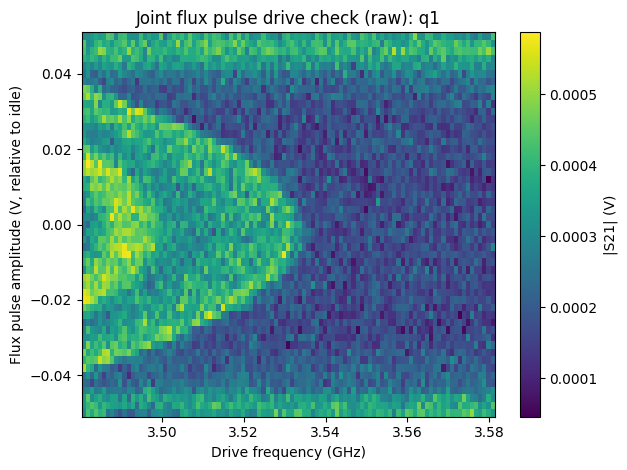

In [18]:
drive_experiment.plot_data()

### Analysis

In [28]:
# Look at drive_experiment.plot_data() (raw grid, above) first and read off
# by eye the flux window where the real dome is unambiguous, plus a rough
# (flux, frequency) guess of where the sweet spot sits -- automatic
# selection alone can still be fooled by a second state / stray strong
# pixel at high leverage (large |flux|), or by seeding from whichever
# pixel is globally loudest instead of the real dome. Set either to None
# to fall back to fully automatic selection for that part.
FLUX_FIT_RANGE = [-0.02, 0.02]  # e.g. (-0.03, 0.03), or None
SWEET_SPOT_GUESS = (3.53e9, 3.54e9)  # (flux V, frequency Hz), or None

drive_results = drive_experiment.analysis(
    flux_range=FLUX_FIT_RANGE, sweet_spot_guess=SWEET_SPOT_GUESS
)
for qubit, result in drive_results.items():
    if result.success:
        print(
            f"{qubit}: sweet_spot={result.sweet_spot:.6f} V (relative to idle bias), "
            f"sweet_spot_frequency={result.sweet_spot_frequency / 1e9:.9f} GHz"
        )
    else:
        print(f"{qubit}: fit failed")

q1: sweet_spot=0.001176 V (relative to idle bias), sweet_spot_frequency=3.492712126 GHz


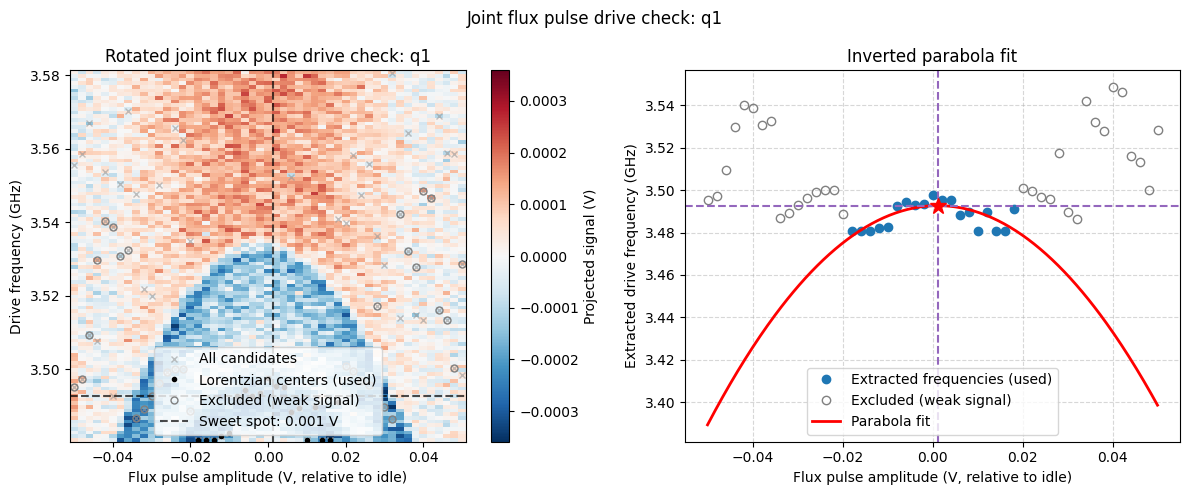

In [29]:
if PLOT_RESULTS_2:
    drive_experiment.plot()

### Next step

Compare the fitted sweet spot / sweet-spot frequency above against a
`run08_qubit_flux_spectroscopy` run of the same qubit and an equivalent flux
range. If they agree (within the readout SNR you'd expect from measuring at
idle instead of at the swept flux point), the pulse/drive/return-to-idle
timing is validated, and `cal08_qubit_flux_spectroscopy.py` can be rebuilt on
top of it to always read out at the idle-tuned resonator frequency.